In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\System -02\Downloads\creditcard.csv\creditcard.csv")
df.drop_duplicates()
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [9]:
#Reducing  
df= df.sample(10000,random_state=42).reset_index(drop=True)
print(df.shape)
print(df['Class'].value_counts())

(10000, 31)
Class
0    9984
1      16
Name: count, dtype: int64


In [11]:
#Null check
print(df.isnull().sum().sort_values(ascending=False).head(3))

#basic stats
print(df[['Amount','Time']].describe())

# fraud vs non fraud amount comparison
print(df.groupby('Class')['Amount'].mean())

Time      0
V16       0
Amount    0
dtype: int64
             Amount           Time
count  10000.000000   10000.000000
mean      86.514139   94440.544900
std      229.830512   47234.811924
min        0.000000       0.000000
25%        5.370000   54109.000000
50%       21.715000   84131.500000
75%       76.457500  138800.000000
max     5239.500000  172782.000000
Class
0     86.293834
1    223.984375
Name: Amount, dtype: float64


C:\Users\System -02\AppData\Local\Temp\ipykernel_2708\1415884945.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class',y='Time',data=df,ax=axes[1,0],palette='Set1')
C:\Users\System -02\AppData\Local\Temp\ipykernel_2708\1415884945.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class',y='Amount',data= df,ax=axes[1,1],palette='coolwarm')


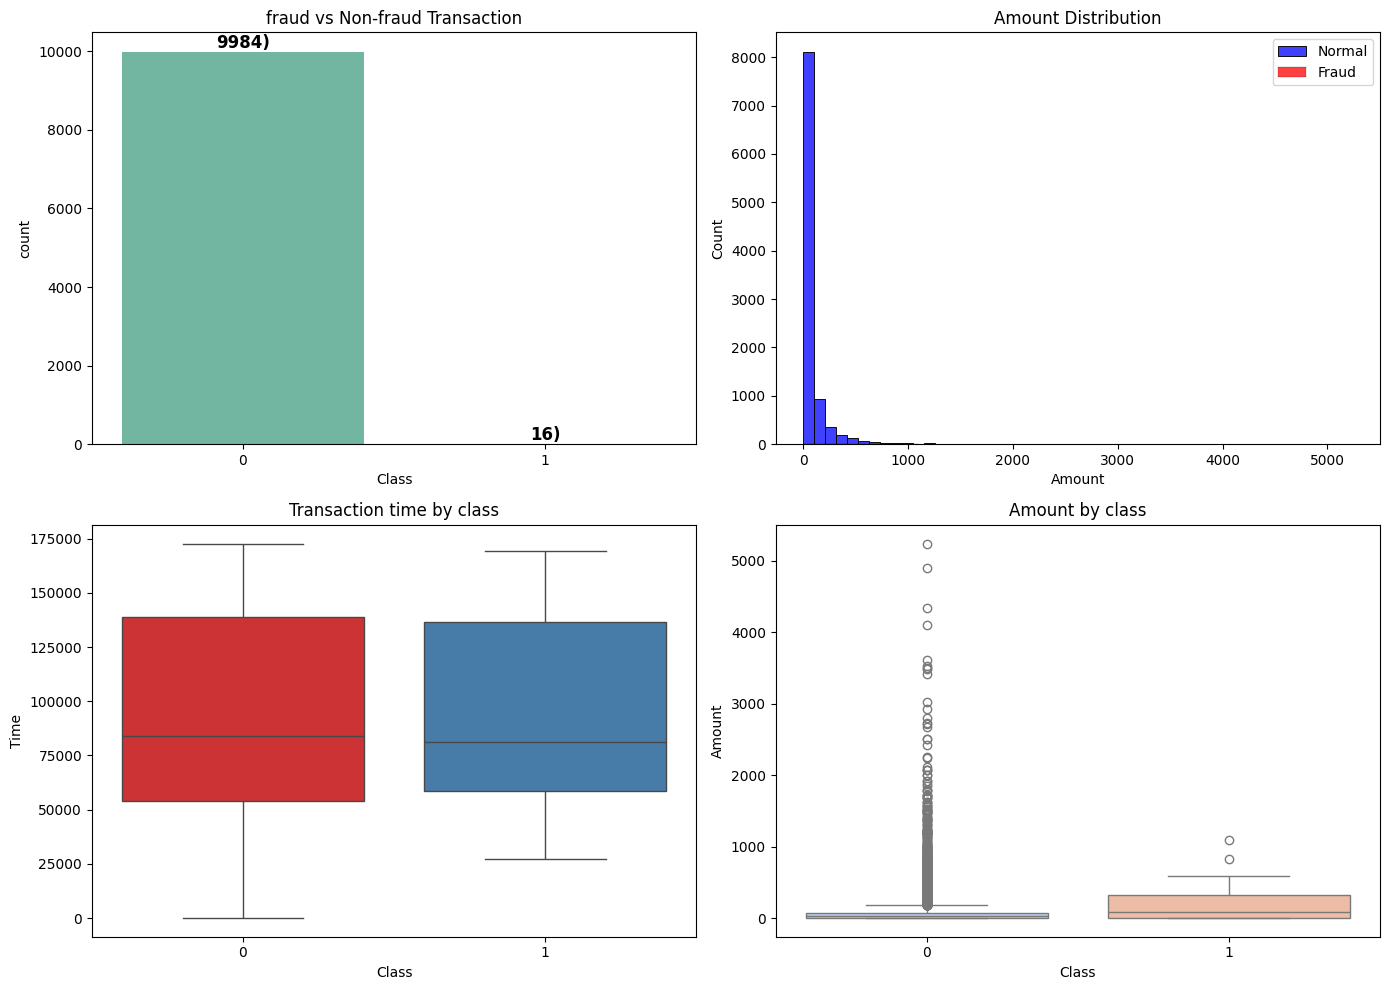

In [15]:
#fraud vs non fraud count
fig,axes = plt.subplots(2,2,figsize =(14,10))
ax = axes[0,0]
sns.countplot(x='Class',data=df,ax=ax,hue='Class',palette='Set2',legend=False)
ax.set_title('fraud vs Non-fraud Transaction') 
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())})',
                (p.get_x()+p.get_width()/2,p.get_height()),
                ha ='center',va='bottom',fontsize =12,fontweight ='bold')
# transaction amount distribution
sns.histplot(df[df['Class']==0]['Amount'],ax=axes[0,1],color='blue',label='Normal',bins=50)
sns.histplot(df[df['Class']==1]['Amount'],ax=axes[0,1],color='red',label='Fraud',bins=50)
axes[0,1].set_title('Amount Distribution')
axes[0,1].legend()

#Transaction time by class
sns.boxplot(x='Class',y='Time',data=df,ax=axes[1,0],palette='Set1')
axes[1,0].set_title('Transaction time by class')

# fraud amount boxplot
sns.boxplot(x='Class',y='Amount',data= df,ax=axes[1,1],palette='coolwarm')
axes[1,1].set_title('Amount by class')

plt.tight_layout()
plt.savefig('fraud_analysis.png',dpi=150)
plt.show()